In [126]:
#importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pylab import rcParams
import seaborn as sb

In [127]:
#import dataset 
import os
import openpyxl
pwd = os.getcwd()
dataset = pd.read_excel(pwd + "/data/DATA.xlsx")
dataset_copy = dataset.copy()
dataset_copy.head(4)

,Datetime,Date,Year,Month,Day,Time,Hour,Temperature,Holiday,Daytype,Frequency of use [Cooker],Frequency of use [Light],Frequency of use [Laptop],Frequency of use [Kettle],Frequency of use [Fan],Frequency of use [Ipod/Tab/Phone],Frequency of use in a day [Iron],Power
0,2022-09-01 00:00:00,2022-09-01,2022,9,1,00:00,0,23.82,1,Thursday,Low,Medium,Medium,Low,High,Medium,Low,NaN
1,2022-09-01 01:00:00,2022-09-01,2022,9,1,01:00,1,23.68,1,Thursday,Low,Medium,Medium,Low,High,Medium,Low,NaN
2,2022-09-01 02:00:00,2022-09-01,2022,9,1,02:00,2,23.61,1,Thursday,Low,Medium,Medium,Low,High,Medium,Low,NaN
3,2022-09-01 03:00:00,2022-09-01,2022,9,1,03:00,3,23.56,1,Thursday,Low,Medium,Medium,Low,High,Medium,Low,NaN


In [128]:
#run when modeling-alternative
dataset_copy.drop(['Time', 'Date'], inplace=True, axis=1)

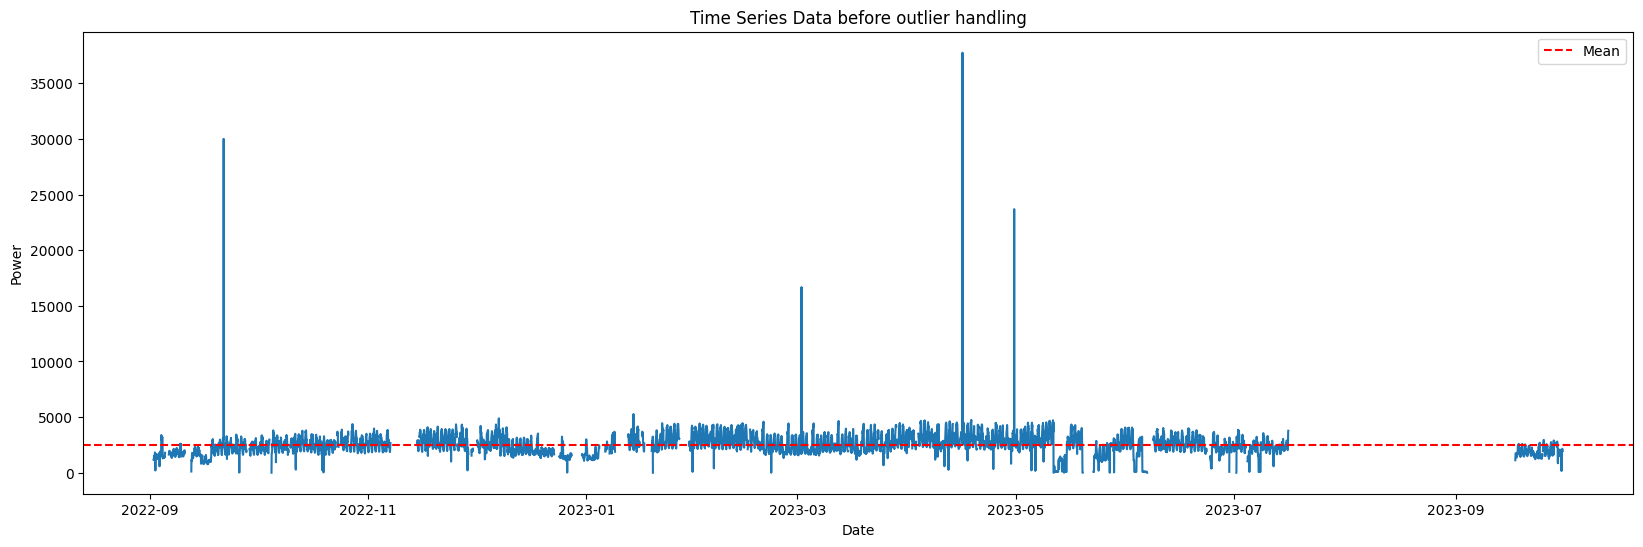

In [129]:
# Visual Inspection - Plot the data with missing values
plt.figure(figsize=(20, 6))
dataset_copy.set_index('Datetime', inplace=True)
plt.plot(dataset_copy['Power'])
plt.xlabel('Date')
plt.ylabel('Power')
plt.title('Time Series Data before outlier handling')
plt.axhline(y=dataset['Power'].mean(), color='r', linestyle='--', label='Mean')
plt.legend()
plt.show()

In [130]:
#handling outlier using IQR - interquantile range
upper = dataset_copy['Power'].quantile(0.75)
lower = dataset_copy['Power'].quantile(0.25)
IQR = upper - lower
max_threshold = upper + (1.5 * IQR)
min_threshold = lower - (1.5 * IQR)

In [131]:
#capping outlier
dataset_copy['Power'] = np.where(dataset_copy['Power']>max_threshold, max_threshold, np.where(dataset_copy['Power']<min_threshold, min_threshold,dataset_copy['Power'] ))

In [132]:
#fill missing value with mean
mean = dataset_copy['Power'].mean()
dataset_copy['Power']= dataset_copy['Power'].fillna(mean)
#dataset_copy.dropna(inplace=True)

In [133]:
# converts to numpy array format
X = dataset_copy.iloc[:,:-1].values
Y = dataset_copy.iloc[:,14:].values

In [134]:
#encoding categorical data
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers = [('encoder', OneHotEncoder(), [6,7,8,9,10,11,12,13])], remainder = 'passthrough')
X =  np.array(ct.fit_transform(X))

In [135]:
#splitting Dataset into training and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [136]:
#splitting training into validation and train
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [137]:
#Data normalization
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train[:,26] = sc.fit_transform(X_train[:,26].reshape(-1, 1)).flatten()
X_test[:,26] = sc.fit_transform(X_test[:,26].reshape(-1, 1)).flatten()
X_val[:,26] = sc.fit_transform(X_val[:,26].reshape(-1, 1)).flatten()

In [138]:
y_train = y_train.flatten()
y_test = y_test.flatten()
y_val = y_val.flatten()

In [139]:

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from xgboost import XGBRegressor

# Create the XGBoost model
model = XGBRegressor(n_estimators=485, learning_rate=0.2, max_depth = 6,  early_stopping_rounds=50)  # You can adjust these hyperparameters

# Train the model
model.fit(X_train, y_train, eval_set=[(X_train, y_train),(X_val, y_val)],  verbose=True)

# Make predictions on the testing set
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)
y_pred = model.predict(X_test)


[0]	validation_0-rmse:649.82758	validation_1-rmse:669.59518
[1]	validation_0-rmse:607.07328	validation_1-rmse:628.01773
[2]	validation_0-rmse:577.53785	validation_1-rmse:600.69434
[3]	validation_0-rmse:553.70725	validation_1-rmse:579.18425
[4]	validation_0-rmse:537.08664	validation_1-rmse:564.82090
[5]	validation_0-rmse:519.01516	validation_1-rmse:551.67659
[6]	validation_0-rmse:505.82728	validation_1-rmse:537.52475
[7]	validation_0-rmse:496.69731	validation_1-rmse:530.45532
[8]	validation_0-rmse:479.35815	validation_1-rmse:514.37731
[9]	validation_0-rmse:472.27368	validation_1-rmse:507.51410
[10]	validation_0-rmse:460.36576	validation_1-rmse:498.37872
[11]	validation_0-rmse:451.75522	validation_1-rmse:493.77401
[12]	validation_0-rmse:439.76117	validation_1-rmse:482.11576
[13]	validation_0-rmse:432.20446	validation_1-rmse:476.88893
[14]	validation_0-rmse:423.75038	validation_1-rmse:469.69742
[15]	validation_0-rmse:420.07666	validation_1-rmse:467.62373
[16]	validation_0-rmse:415.27804	v

In [140]:
# Evaluate the model
mse_train = mean_squared_error(y_train, y_train_pred)
mae_train = mean_absolute_error(y_train, y_train_pred)
mape_train = mean_absolute_percentage_error(y_train, y_train_pred)

mse_val = mean_squared_error(y_val, y_val_pred)
mae_val = mean_absolute_error(y_val, y_val_pred)
mape_val = mean_absolute_percentage_error(y_val, y_val_pred)

mse_test = mean_squared_error(y_test, y_pred)
mae_test = mean_absolute_error(y_test, y_pred)
mape_test = mean_absolute_percentage_error(y_test, y_pred)

print("Mean Squared Error (MSE-TRAIN):", mse_train)
print("Mean Absolute Error (MAE-TRAIN):", mae_train)
print("Mean Absolute Percentage Error (MAPE-TRAIN):", mape_train)
print("-------------------------------------------------")
print("Mean Squared Error (MSE-VAL):", mse_val)
print("Mean Absolute Error (MAE-VAL):", mae_val)
print("Mean Absolute Percentage Error (MAPE-VAL):", mape_val)
print("-------------------------------------------------")
print("Mean Squared Error (MSE-TEST):", mse_test)
print("Mean Absolute Error (MAE-TEST):", mae_test)
print("Mean Absolute Percentage Error (MAPE-TEST):", mape_test)

Mean Squared Error (MSE-TRAIN): 5503.339627105976
Mean Absolute Error (MAE-TRAIN): 51.557534965388776
Mean Absolute Percentage Error (MAPE-TRAIN): 0.02723843701649374
-------------------------------------------------
Mean Squared Error (MSE-VAL): 123488.32496878615
Mean Absolute Error (MAE-VAL): 225.21765372062762
Mean Absolute Percentage Error (MAPE-VAL): 0.12885080652253025
-------------------------------------------------
Mean Squared Error (MSE-TEST): 117506.00529013929
Mean Absolute Error (MAE-TEST): 218.97901938994266
Mean Absolute Percentage Error (MAPE-TEST): 0.11452120073255496


In [141]:
# Create a DataFrame to display actual and predicted values---xgboost
results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print("Actual vs Predicted:")
results_df.head(10)

Actual vs Predicted:


,Actual,Predicted
0,353.625000,852.545349
1,2116.000000,2146.769531
2,2511.614075,2561.849365
3,4049.000000,3516.452148
4,2409.000000,2348.302979
5,1425.000000,1758.750977
6,3475.000000,3462.046631
7,2511.614075,2583.517090
8,1909.000000,1855.314331
9,4110.000000,4278.244629


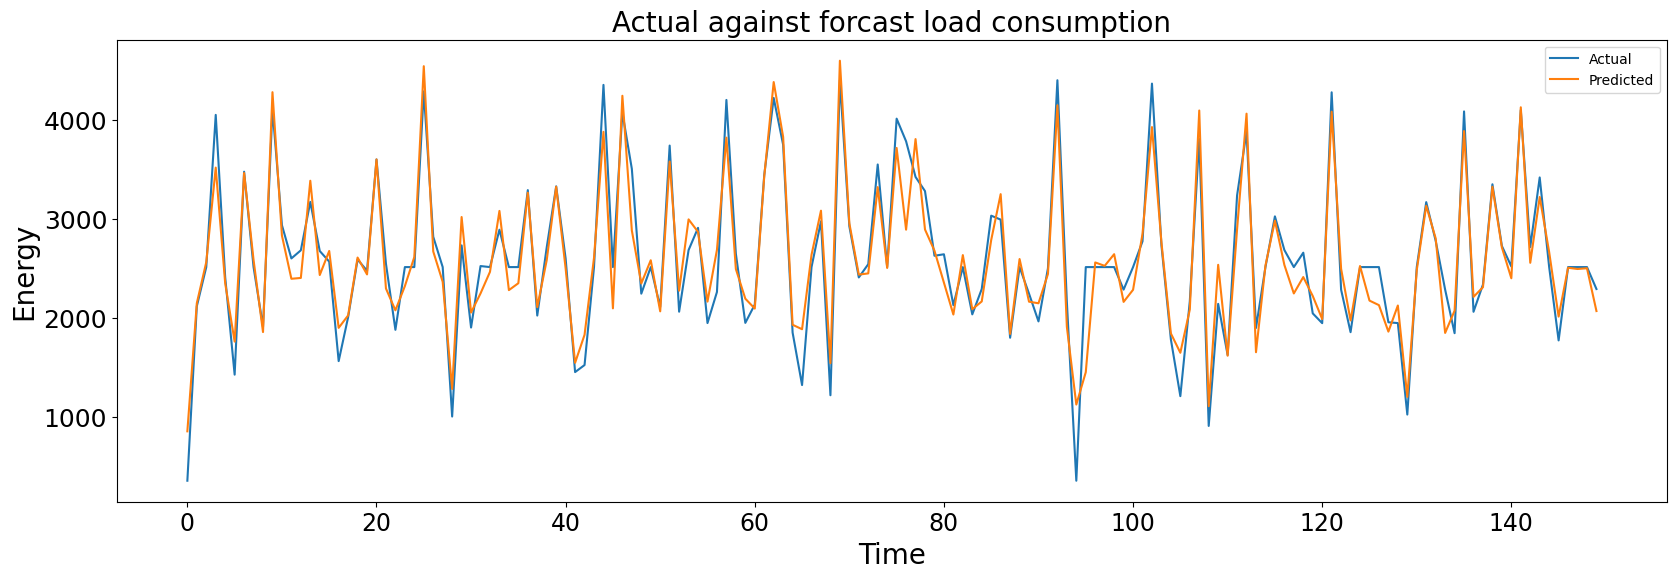

In [142]:
# Visual Inspection - Plot the data with missing values
plt.figure(figsize=(20, 6))
plt.plot(results_df['Actual'].head(150), label="Actual")
plt.plot(results_df['Predicted'].head(150), label="Predicted")
plt.title('Actual against forcast load consumption', fontsize=20)
plt.tick_params(axis='x', labelsize=17)
plt.tick_params(axis='y', labelsize=18)
plt.xlabel('Time', fontsize=20)
plt.ylabel('Energy', fontsize=20)
plt.legend()
plt.show()

In [143]:
# Extract support vectors, coefficients, and intercept
support_vectors = svr_model.support_vectors_
coefficients = svr_model.dual_coef_
intercept = svr_model.intercept_
gamma = svr_model.gamma

In [144]:
count = 0
for i in coefficients[0]:
    count = count + 1
    print(i)

-20000.0
-20000.0
5386.529125058902
-14855.502278506656
-20000.0
20000.0
19366.60726248811
20000.0
-1207.780471289337
20000.0
1567.5059770210503
-20000.0
4890.114759403204
20000.0
20000.0
-20000.0
16267.732431168306
20000.0
-20000.0
-20000.0
-6151.87569760408
-20000.0
20000.0
-20000.0
20000.0
20000.0
9882.09123342158
-20000.0
-15390.290247087974
20000.0
20000.0
11717.070495026574
15089.454827783908
-20000.0
-20000.0
-2841.429430101999
3409.9559780501404
-102.6762599859892
20000.0
-8908.997590045314
-2559.4147502755022
16900.81233828845
-20000.0
20000.0
-20000.0
-20000.0
-20000.0
20000.0
-3717.3134826234655
-20000.0
-7354.764241326841
-20000.0
-7036.782836223741
-3892.739174608234
-20000.0
-5690.521941143513
-18909.200213085947
1439.6881117227413
20000.0
6450.73726590371
20000.0
7537.114534501459
-14847.721913111174
-20000.0
18641.138675816266
20000.0
20000.0
-9930.044677458272
13878.247493500885
-20000.0
-16347.43876372408
-8123.890803178693
20000.0
-20000.0
8602.671779687638
279.97732

In [145]:
count

6063

In [146]:
intercept

array([2112.02588469])